[![Open In Collab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AIPI-590-XAI/Duke-AI-XAI/blob/main/assignments/xai_decathlon.ipynb)

# XAI Decathlon: Round 1 Individual Method Trial

In this lab, each student works with **one assigned explainability method** and tries to use it across ten explanation events.

The notebook gives you:

- Two trained target models: one tabular model and one image model.
- Ten event prompts with ready-to-use model objects, data objects, and assigned cases.
- A markdown results table to fill in as you go.
- A final model-profile prompt for summarizing what your method can and cannot support.

The notebook does **not** implement LIME, SHAP, PDP, ALE, Grad-CAM, Score-CAM, saliency, counterfactuals, or any other explanation method for you. That is the challenge.

**Estimated time:** 60-75 minutes  
**Format:** individual method trial  
**Deliverable:** a completed results table plus a short model profile


## Core Lesson

Different explanation methods answer different kinds of questions.

Your job is to find out where your assigned method is useful, where it is only partially useful, and where it simply does not fit the task. A method can earn a strong score for saying something clear and justified, including: "this method cannot answer this event question."

This notebook is intentionally only the individual round. Later, you may compare results with classmates who used different methods.


## Scoring Rules

For each event, assign your method one medal:

- **Gold:** directly answers the event question with convincing evidence.
- **Silver:** gives useful partial evidence, but another method or assumption is needed.
- **Bronze:** gives weak, indirect, or fragile evidence.
- **DNF:** does not finish: the method is mismatched, misleading, or not usable for the event.

A pretty visualization is not automatically a medal. Score the method based on whether it answers the event question.


## The Ten Events

| Event | Question |
|---|---|
| 1. Most Important Feature | What variable most strongly influences the tabular model's predictions? |
| 2. One Specific Prediction | Why did this individual tabular prediction occur? |
| 3. Dataset Bias or Shortcut | Is the image model relying on a spurious shortcut? |
| 4. Global Feature Effect | As one tabular feature changes, what happens to predictions? |
| 5. Compare Two Predictions | Why were two cases classified differently? |
| 6. Feature Interactions | Which tabular variables work together? |
| 7. Where Is the Model Looking? | What region of an image drives the prediction? |
| 8. Explain a Failure | Why did the model make this mistake? |
| 9. Estimate Trustworthiness | Should a human trust this prediction? |
| 10. Reverse Engineer Strategy | What strategy has each model learned? |

## Results Table

Edit this markdown cell as you work through the events. Keep each evidence claim short enough that someone else can understand what your method showed and why you assigned the medal.

**My assigned method:** SHAP (TreeExplainer for the random forest, GradientExplainer for the CNN)
 

| Event | Question | Medal | Evidence from my method | Limitations or notes |
|---|---|---|---|---|
| 1. Most Important Feature | What variable most strongly influences the tabular model's predictions? | Gold | Mean \|SHAP\|: debt_ratio is highest (0.077), then zip_proxy (0.054) and recent_late_payments (0.045). app_minutes, age and support_tickets are close to 0. | Shows what the model uses, not what causes risk. I checked correlations since SHAP can split credit between them, but the highest was about 0.25, so I don't think it changes the ranking much. |
| 2. One Specific Prediction | Why did this individual tabular prediction occur? | Gold | Row 718 (P = 0.499). Base 0.224 plus SHAP sum 0.275. zip_proxy = 1 adds 0.154 by itself, income, savings and late payments add about 0.04 each, low debt_ratio lowers it a bit. | Values change a little depending on which TreeSHAP setting you use (checked in Event 9, difference was small). |
| 3. Dataset Bias or Shortcut | Is the image model relying on a spurious shortcut? | Gold | The marker area is 3.5% of the image but gets around 80% of the \|SHAP\| when the marker is there, and still 66 to 69% when it isn't. The shape only gets about 8 to 17% on average. The circle with a marker is predicted square with P = 0.98. | This is attribution, not an actual test. Removing the marker and checking the prediction would be stronger proof. |
| 4. Global Feature Effect | As one tabular feature changes, what happens to predictions? | Silver | debt_ratio dependence plot: flat (around -0.07) below 0.25, goes up fast between 0.25 and 0.6, flat again (around +0.22) above 0.6. Higher income lowers risk. | The dependence plot shows SHAP values, not the prediction itself as the feature changes. PDP or ALE fit this question better. Only 4 rows above 0.7. |
| 5. Compare Two Predictions | Why were two cases classified differently? | Gold | Low case 0.022 vs high case 0.789. The 0.766 gap splits into debt_ratio 0.225, late payments 0.211, zip_proxy 0.129, income 0.089 and so on. For two true squares, the only big difference is the marker area. | Works nicely because both rows have the same base value. It doesn't say what small change would flip one into the other. |
| 6. Feature Interactions | Which tabular variables work together? | Silver | Top interaction pairs: debt_ratio x recent_late_payments, income_k x zip_proxy, debt_ratio x zip_proxy. age x debt_ratio shows up only for young people with high debt. | Only works because it's a tree model. Some of the "interactions" are probably just because the output is a probability. app_minutes x zip_proxy came out 5th even though app_minutes barely matters. The age x debt effect only had 11 rows and I only found it because I looked for it. |
| 7. Where Is the Model Looking? | What region of an image drives the prediction? | Gold | All four heatmaps light up the top left corner. The average map over 120 images looks the same, the shape edges are barely visible. | Pixel SHAP is noisy and depends on the background. It shows where, but not if it's the color or the position. |
| 8. Explain a Failure | Why did the model make this mistake? | Silver | Image: circle with marker is called square, around 80% of SHAP is on the marker (same situation as Event 3). Tabular: row 1 is actually high risk but got 0.40. debt_ratio pushes up 0.24 but only 1 late payment and zip_proxy = 0 pull it back down. | SHAP tells what the model used, not why the label is different. The labels have random noise so some mistakes can't really be explained. |
| 9. Estimate Trustworthiness | Should a human trust this prediction? | Silver | Row 718 is basically 50/50 and mostly driven by zip_proxy, and zip_proxy is the top driver in 24% of rows, so I wouldn't trust these without checking. Image model: no, it uses the marker. Explanations were stable in both checks. | SHAP can give reasons not to trust something but it can't show that a prediction is correct. No uncertainty or calibration info. |
| 10. Reverse Engineer Strategy | What strategy has each model learned? | Silver | Tabular: high debt, late payments, zip_proxy = 1 and low income mean high risk. Image: red corner means square, no red corner means circle. | Mostly descriptive. Didn't get exact rules (like age < 30) and didn't test anything causally. |

In [1]:
# @title Setup
# Run this cell first. It imports only the libraries needed to create the target models.
# You may add your own XAI imports later in the "Your method implementation" section.

import math
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True

SEED = 42
rng = np.random.default_rng(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cpu


In [2]:
# @title Event guide helper
# This table points you to the model/data objects for each event.

EVENTS = [
    "1. Most important feature",
    "2. One specific prediction",
    "3. Dataset bias or shortcut",
    "4. Global feature effect",
    "5. Compare two predictions",
    "6. Feature interactions",
    "7. Where is the model looking?",
    "8. Explain a failure",
    "9. Estimate trustworthiness",
    "10. Reverse engineer strategy",
]

event_guide = pd.DataFrame(
    {
        "event": EVENTS,
        "target": [
            "Tabular risk model",
            "Tabular risk model",
            "Image shortcut model",
            "Tabular risk model",
            "Tabular or image cases",
            "Tabular risk model",
            "Image shortcut model",
            "Tabular or image failure case",
            "Either target model",
            "Both target models",
        ],
        "primary_objects": [
            "risk_model, X_train, X_test, feature_names, predict_risk_proba",
            "tabular_local_case, X_test, predict_risk_proba",
            "image_shortcut_case, image_reference_case, test_imgs, predict_image_proba",
            "X_train, X_test, feature_names, predict_risk_proba",
            "tabular_low_case vs tabular_high_case, or assigned_image_cases",
            "X_train, X_test, feature_names, predict_risk_proba",
            "image_model, test_imgs, assigned_image_cases, show_image_case",
            "tabular_failure_case or image_failure_case",
            "assigned cases, predicted probabilities, explanation stability checks",
            "all model interfaces and prior event evidence",
        ],
        "question_type": [
            "global feature importance",
            "local prediction explanation",
            "shortcut or bias diagnosis",
            "global feature effect",
            "contrastive explanation",
            "interaction discovery",
            "spatial localization",
            "failure diagnosis",
            "trust and uncertainty judgment",
            "synthesis and model profiling",
        ],
    }
)

event_guide

,event,target,primary_objects,question_type
0,1. Most important feature,Tabular risk model,"risk_model, X_train, X_test, feature_names, pr...",global feature importance
1,2. One specific prediction,Tabular risk model,"tabular_local_case, X_test, predict_risk_proba",local prediction explanation
2,3. Dataset bias or shortcut,Image shortcut model,"image_shortcut_case, image_reference_case, tes...",shortcut or bias diagnosis
3,4. Global feature effect,Tabular risk model,"X_train, X_test, feature_names, predict_risk_p...",global feature effect
4,5. Compare two predictions,Tabular or image cases,"tabular_low_case vs tabular_high_case, or assi...",contrastive explanation
5,6. Feature interactions,Tabular risk model,"X_train, X_test, feature_names, predict_risk_p...",interaction discovery
6,7. Where is the model looking?,Image shortcut model,"image_model, test_imgs, assigned_image_cases, ...",spatial localization
7,8. Explain a failure,Tabular or image failure case,tabular_failure_case or image_failure_case,failure diagnosis
8,9. Estimate trustworthiness,Either target model,"assigned cases, predicted probabilities, expla...",trust and uncertainty judgment
9,10. Reverse engineer strategy,Both target models,all model interfaces and prior event evidence,synthesis and model profiling


# Target Model 1: Tabular Risk Model

You are given a trained model that predicts whether a synthetic applicant is **high risk**.

The model sees these features:

- `age`
- `income_k`
- `debt_ratio`
- `loyalty_years`
- `recent_late_payments`
- `savings_k`
- `app_minutes`
- `support_tickets`
- `zip_proxy`
- `promo_seen`

Treat this as a model you need to investigate. Some variables are directly meaningful, some are weak, some may act like shortcuts, and some may interact.

In [3]:
# @title Create the tabular data and train the risk model


def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def make_tabular_data(n=3000, seed=SEED):
    rng = np.random.default_rng(seed)
    age = rng.integers(18, 76, size=n)
    income_k = np.clip(rng.normal(72, 24, size=n), 18, 180)
    debt_ratio = np.clip(rng.beta(2.2, 5.0, size=n), 0.01, 0.98)
    loyalty_years = np.clip((age - 18) * rng.beta(1.5, 6.0, size=n), 0, 35)
    recent_late_payments = rng.poisson(0.65 + 1.8 * debt_ratio, size=n)
    savings_k = np.clip(rng.lognormal(mean=2.35, sigma=0.8, size=n), 0, 120)
    app_minutes = np.clip(rng.normal(18, 7, size=n), 2, 60)
    support_tickets = rng.poisson(0.3 + 0.5 * (debt_ratio > 0.45), size=n)

    zip_proxy = rng.binomial(
        1, sigmoid(-0.9 + 1.9 * debt_ratio - 0.012 * income_k), size=n
    )
    promo_seen = rng.binomial(
        1, sigmoid(-0.3 + 1.4 * zip_proxy + 0.8 * (age < 30)), size=n
    )
    young_high_debt = ((age < 30) & (debt_ratio > 0.48)).astype(float)

    logit = (
        -1.9
        + 3.8 * debt_ratio
        + 0.38 * recent_late_payments
        - 0.018 * income_k
        - 0.024 * savings_k
        - 0.045 * loyalty_years
        + 0.85 * zip_proxy
        + 0.55 * promo_seen
        + 1.25 * young_high_debt
        + 0.025 * support_tickets
        + rng.normal(0, 0.45, size=n)
    )
    p = sigmoid(logit)
    y = rng.binomial(1, p)

    X = pd.DataFrame(
        {
            "age": age,
            "income_k": income_k,
            "debt_ratio": debt_ratio,
            "loyalty_years": loyalty_years,
            "recent_late_payments": recent_late_payments,
            "savings_k": savings_k,
            "app_minutes": app_minutes,
            "support_tickets": support_tickets,
            "zip_proxy": zip_proxy,
            "promo_seen": promo_seen,
        }
    )
    return X, pd.Series(y, name="high_risk")


X, y = make_tabular_data()
feature_names = X.columns.tolist()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=SEED, stratify=y
)

risk_model = RandomForestClassifier(
    n_estimators=220,
    max_depth=7,
    min_samples_leaf=12,
    random_state=SEED,
    n_jobs=-1,
)
risk_model.fit(X_train, y_train)

tabular_pred = risk_model.predict(X_test)
tabular_proba = risk_model.predict_proba(X_test)[:, 1]

print("Accuracy:", round(accuracy_score(y_test, tabular_pred), 3))
print("Positive class rate in test set:", round(float(y_test.mean()), 3))
print(
    classification_report(y_test, tabular_pred, target_names=["low risk", "high risk"])
)
X_train.head()

Accuracy: 0.805
Positive class rate in test set: 0.224
              precision    recall  f1-score   support

    low risk       0.81      0.97      0.89       582
   high risk       0.70      0.23      0.34       168

    accuracy                           0.81       750
   macro avg       0.76      0.60      0.61       750
weighted avg       0.79      0.81      0.76       750



,age,income_k,debt_ratio,loyalty_years,recent_late_payments,savings_k,app_minutes,support_tickets,zip_proxy,promo_seen
1583,42,60.186070,0.178157,3.750431,2,12.938567,8.853330,1,0,1
1035,61,125.055381,0.136064,3.955724,0,7.920787,8.808620,0,0,1
657,54,74.580820,0.488986,16.918809,1,2.733885,18.188498,0,0,0
968,71,71.595919,0.282121,7.306052,0,2.729296,19.732005,1,0,1
2298,30,81.528758,0.200992,0.374701,2,4.948344,13.871067,0,1,1


In [4]:
# @title Tabular model interface and assigned cases
# These are allowed utilities. They expose the model and selected cases, but they do not explain the model.


def predict_risk_proba(data):
    """Return [P(low risk), P(high risk)] for rows with the tabular feature columns."""
    if isinstance(data, pd.DataFrame):
        df = data[feature_names]
    else:
        df = pd.DataFrame(data, columns=feature_names)
    return risk_model.predict_proba(df)


def first_distinct(candidates, used=(), fallback=0):
    """Pick the first candidate that is not already used."""
    for idx in candidates:
        idx = int(idx)
        if idx not in used:
            return idx
    return int(fallback)


# Cases for local, comparison, and failure events.
tabular_low_case = int(np.argmin(tabular_proba))
tabular_high_case = int(np.argmax(tabular_proba))
near_boundary_rows = np.argsort(np.abs(tabular_proba - 0.5))
tabular_local_case = first_distinct(
    near_boundary_rows, used={tabular_low_case, tabular_high_case}
)
wrong_rows = np.where(tabular_pred != y_test.to_numpy())[0]
tabular_failure_case = first_distinct(
    wrong_rows,
    used={tabular_local_case, tabular_low_case, tabular_high_case},
    fallback=tabular_local_case,
)

assigned_tabular_cases = pd.DataFrame(
    {
        "case_name": ["local_case", "low_case", "high_case", "failure_case"],
        "row_index_in_X_test": [
            tabular_local_case,
            tabular_low_case,
            tabular_high_case,
            tabular_failure_case,
        ],
        "true_label": [
            int(y_test.iloc[tabular_local_case]),
            int(y_test.iloc[tabular_low_case]),
            int(y_test.iloc[tabular_high_case]),
            int(y_test.iloc[tabular_failure_case]),
        ],
        "predicted_label": [
            int(tabular_pred[tabular_local_case]),
            int(tabular_pred[tabular_low_case]),
            int(tabular_pred[tabular_high_case]),
            int(tabular_pred[tabular_failure_case]),
        ],
        "predicted_P_high_risk": [
            round(float(tabular_proba[tabular_local_case]), 3),
            round(float(tabular_proba[tabular_low_case]), 3),
            round(float(tabular_proba[tabular_high_case]), 3),
            round(float(tabular_proba[tabular_failure_case]), 3),
        ],
    }
)

assigned_tabular_cases

,case_name,row_index_in_X_test,true_label,predicted_label,predicted_P_high_risk
0,local_case,718,0,0,0.499
1,low_case,565,0,0,0.022
2,high_case,564,1,1,0.789
3,failure_case,1,1,0,0.400


# Target Model 2: Image Shortcut Model

You are given a tiny image classifier trained on synthetic images.

- Class `0`: circle
- Class `1`: square

The training data may contain a shortcut. The test set is designed so you can investigate whether the model learned the intended shape concept, a shortcut, or both.

In [5]:
# @title Create the image data and train the image model


def draw_shape_image(label, marker=None, seed=None, image_size=64):
    rng = np.random.default_rng(seed)
    img = np.ones((image_size, image_size, 3), dtype=np.float32) * 0.92
    img += rng.normal(0, 0.025, size=img.shape).astype(np.float32)
    img = np.clip(img, 0, 1)

    yy, xx = np.mgrid[:image_size, :image_size]
    cx = image_size // 2 + int(rng.integers(-5, 6))
    cy = image_size // 2 + int(rng.integers(-5, 6))

    color = np.array([0.20, 0.22, 0.24])
    if label == 0:
        radius = int(rng.integers(10, 18))
        mask = (xx - cx) ** 2 + (yy - cy) ** 2 <= radius**2
    else:
        half = int(rng.integers(9, 17))
        mask = (np.abs(xx - cx) <= half) & (np.abs(yy - cy) <= half)

    img[mask] = color

    # The marker is part of the data-generation process. Whether it is fair evidence is for you to investigate.
    if marker is None:
        marker = rng.random() < (0.98 if label == 1 else 0.02)
    if marker:
        img[3:15, 3:15, :] = np.array([0.95, 0.08, 0.08])

    return np.clip(img, 0, 1), int(marker)


def make_image_dataset(n=800, seed=SEED, balanced_markers=False):
    rng = np.random.default_rng(seed)
    images, labels, markers = [], [], []
    for i in range(n):
        label = int(rng.integers(0, 2))
        marker = None
        if balanced_markers:
            marker = bool(rng.integers(0, 2))
        img, has_marker = draw_shape_image(label, marker=marker, seed=seed + i)
        images.append(img)
        labels.append(label)
        markers.append(has_marker)
    return np.stack(images), np.array(labels), np.array(markers)


train_imgs, train_y, train_marker = make_image_dataset(
    800, seed=10, balanced_markers=False
)
test_imgs, test_y, test_marker = make_image_dataset(
    320, seed=5000, balanced_markers=True
)


class TinyShapeCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 12, kernel_size=5, padding=2)
        self.conv2 = nn.Conv2d(12, 24, kernel_size=5, padding=2)
        self.pool = nn.MaxPool2d(2)
        self.fc1 = nn.Linear(24 * 16 * 16, 48)
        self.fc2 = nn.Linear(48, 2)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.flatten(1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)


def to_tensor_images(images):
    return torch.tensor(images.transpose(0, 3, 1, 2), dtype=torch.float32)


train_ds = TensorDataset(
    to_tensor_images(train_imgs), torch.tensor(train_y, dtype=torch.long)
)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)

image_model = TinyShapeCNN().to(DEVICE)
optimizer = torch.optim.Adam(image_model.parameters(), lr=1e-3)

image_model.train()
for epoch in range(4):
    losses = []
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = F.cross_entropy(image_model(xb), yb)
        loss.backward()
        optimizer.step()
        losses.append(float(loss.detach().cpu()))
    print(f"epoch {epoch + 1}: loss={np.mean(losses):.4f}")

image_model.eval()
with torch.no_grad():
    logits = image_model(to_tensor_images(test_imgs).to(DEVICE))
    image_proba = F.softmax(logits, dim=1).cpu().numpy()
    image_pred = image_proba.argmax(axis=1)

print("Test accuracy:", round(accuracy_score(test_y, image_pred), 3))
print("Confusion matrix:\n", confusion_matrix(test_y, image_pred))

epoch 1: loss=0.6577
epoch 2: loss=0.2582
epoch 3: loss=0.0858
epoch 4: loss=0.0954
Test accuracy: 0.494
Confusion matrix:
 [[68 84]
 [78 90]]


In [6]:
# @title Image model interface and assigned cases
# These are allowed utilities. They expose the model and selected cases, but they do not explain the model.


def predict_image_proba(images_np):
    """Return [P(circle), P(square)] for images shaped as N x 64 x 64 x 3."""
    image_model.eval()
    with torch.no_grad():
        xb = to_tensor_images(np.asarray(images_np)).to(DEVICE)
        probs = F.softmax(image_model(xb), dim=1).cpu().numpy()
    return probs


def show_image_case(idx, title_prefix=""):
    probs = predict_image_proba(test_imgs[[idx]])[0]
    plt.imshow(test_imgs[idx])
    plt.axis("off")
    plt.title(
        f"{title_prefix}idx={idx} true={test_y[idx]} pred={probs.argmax()} "
        f"P(square)={probs[1]:.3f} marker={test_marker[idx]}"
    )
    plt.show()


def first_distinct(candidates, used=(), fallback=0):
    """Pick the first candidate that is not already used."""
    for idx in candidates:
        idx = int(idx)
        if idx not in used:
            return idx
    return int(fallback)


image_wrong = np.where(image_pred != test_y)[0]
marker_present_circle = np.where((test_marker == 1) & (test_y == 0))[0]
marker_present_square = np.where((test_marker == 1) & (test_y == 1))[0]
marker_absent_square = np.where((test_marker == 0) & (test_y == 1))[0]
image_shortcut_case = first_distinct(marker_present_circle, fallback=0)
image_reference_case = first_distinct(
    marker_present_square, used={image_shortcut_case}, fallback=0
)
image_contrast_case = first_distinct(
    marker_absent_square,
    used={image_shortcut_case, image_reference_case},
    fallback=1,
)
image_failure_case = first_distinct(
    image_wrong,
    used={image_shortcut_case, image_reference_case, image_contrast_case},
    fallback=image_contrast_case,
)

assigned_image_cases = pd.DataFrame(
    {
        "case_name": [
            "shortcut_probe",
            "reference_square",
            "contrast_square",
            "failure_case",
        ],
        "image_index": [
            image_shortcut_case,
            image_reference_case,
            image_contrast_case,
            image_failure_case,
        ],
        "true_label": [
            int(test_y[image_shortcut_case]),
            int(test_y[image_reference_case]),
            int(test_y[image_contrast_case]),
            int(test_y[image_failure_case]),
        ],
        "marker_present": [
            int(test_marker[image_shortcut_case]),
            int(test_marker[image_reference_case]),
            int(test_marker[image_contrast_case]),
            int(test_marker[image_failure_case]),
        ],
        "predicted_label": [
            int(image_pred[image_shortcut_case]),
            int(image_pred[image_reference_case]),
            int(image_pred[image_contrast_case]),
            int(image_pred[image_failure_case]),
        ],
        "predicted_P_square": [
            round(float(image_proba[image_shortcut_case, 1]), 3),
            round(float(image_proba[image_reference_case, 1]), 3),
            round(float(image_proba[image_contrast_case, 1]), 3),
            round(float(image_proba[image_failure_case, 1]), 3),
        ],
    }
)

assigned_image_cases

,case_name,image_index,true_label,marker_present,predicted_label,predicted_P_square
0,shortcut_probe,5,0,1,1,0.980
1,reference_square,2,1,1,1,0.985
2,contrast_square,4,1,0,0,0.066
3,failure_case,6,0,1,1,0.980


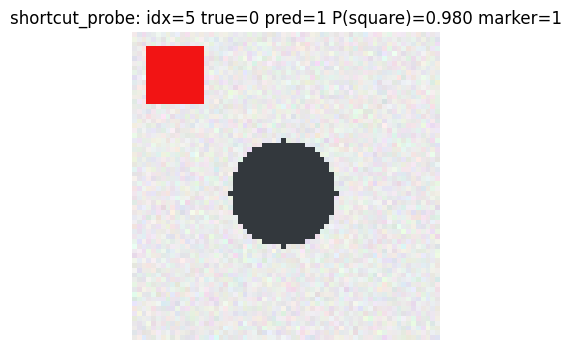

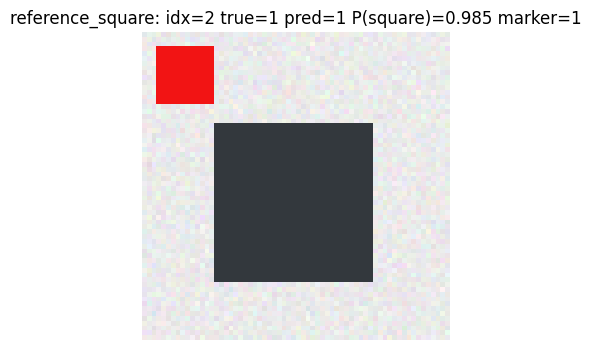

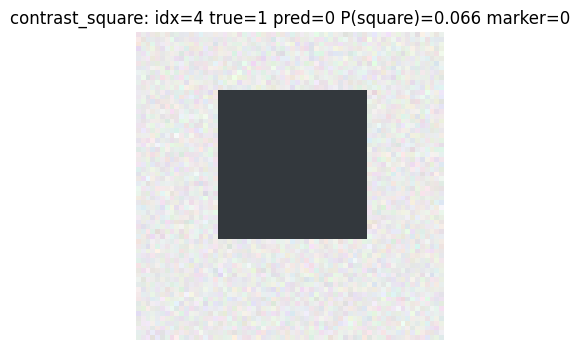

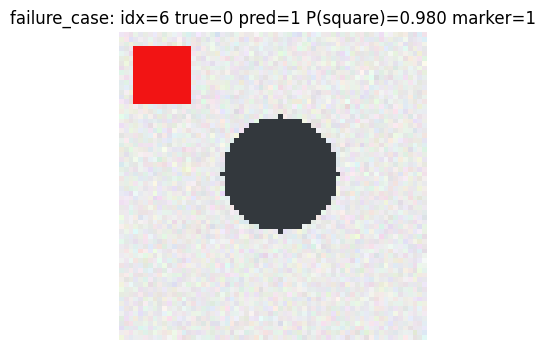

In [7]:
# @title View the assigned image cases
for name, idx in zip(
    assigned_image_cases["case_name"], assigned_image_cases["image_index"]
):
    show_image_case(int(idx), title_prefix=f"{name}: ")

# Your Method Implementation

Use this section to install packages, import libraries, write helper functions, and adapt your assigned XAI method.

You may use external documentation. You may also decide that your method cannot reasonably be applied to an event, but you must explain why.

Suggested workflow:

1. Identify what inputs your method needs: tabular rows, images, gradients, model probabilities, labels, background data, perturbed samples, etc.
2. Decide whether your method is local, global, visual, counterfactual, or something else.
3. Implement the smallest version that can answer one event.
4. Reuse and adapt it across events.
5. Record both successes and failures honestly.


In [8]:
# Your implementation scratchpad.
# Add imports, installations, helper functions, and experiments here.

# Examples of things you might add in Colab, depending on your method:
# !pip install shap lime captum torchcam alibi PyALE
# import shap
# from lime.lime_tabular import LimeTabularExplainer

print("Event guide:")
display(event_guide)

# Keep your method-specific code here or add new cells below.

Event guide:


,event,target,primary_objects,question_type
0,1. Most important feature,Tabular risk model,"risk_model, X_train, X_test, feature_names, pr...",global feature importance
1,2. One specific prediction,Tabular risk model,"tabular_local_case, X_test, predict_risk_proba",local prediction explanation
2,3. Dataset bias or shortcut,Image shortcut model,"image_shortcut_case, image_reference_case, tes...",shortcut or bias diagnosis
3,4. Global feature effect,Tabular risk model,"X_train, X_test, feature_names, predict_risk_p...",global feature effect
4,5. Compare two predictions,Tabular or image cases,"tabular_low_case vs tabular_high_case, or assi...",contrastive explanation
5,6. Feature interactions,Tabular risk model,"X_train, X_test, feature_names, predict_risk_p...",interaction discovery
6,7. Where is the model looking?,Image shortcut model,"image_model, test_imgs, assigned_image_cases, ...",spatial localization
7,8. Explain a failure,Tabular or image failure case,tabular_failure_case or image_failure_case,failure diagnosis
8,9. Estimate trustworthiness,Either target model,"assigned cases, predicted probabilities, expla...",trust and uncertainty judgment
9,10. Reverse engineer strategy,Both target models,all model interfaces and prior event evidence,synthesis and model profiling


In [9]:
# SHAP setup
!pip install -q shap
import shap
from matplotlib.patches import Rectangle

print("shap version:", shap.__version__)

# tabular model -> TreeExplainer (exact SHAP for tree models)
# for a RF classifier the values are in probability units, so
# P(high risk) = base value + sum of shap values
tree_explainer = shap.TreeExplainer(risk_model)

X_shap = X_test.sample(400, random_state=SEED)  # sample used for the global plots
tab_sv = tree_explainer(X_shap)[:, :, 1]  # class 1 = high risk
TAB_BASE = float(np.ravel(tab_sv.base_values)[0])
print("base value:", round(TAB_BASE, 3))


def tabular_shap_row(idx):
    return tree_explainer(X_test.iloc[[idx]])[:, :, 1][0]


def shap_table(idx):
    e = tabular_shap_row(idx)
    df = pd.DataFrame(
        {"value": X_test.iloc[idx].values, "shap": e.values}, index=feature_names
    )
    return df.sort_values("shap", key=np.abs, ascending=False).round(4)


# image model -> GradientExplainer
# background = 100 random training images
bg_idx = np.random.default_rng(SEED).choice(len(train_imgs), 100, replace=False)
image_background = to_tensor_images(train_imgs[bg_idx]).to(DEVICE)
image_model.eval()
grad_explainer = shap.GradientExplainer(image_model, image_background)


def image_shap(idxs, nsamples=200, explainer=None):
    # returns N x 64 x 64 x 2, summed over RGB. [..., 1] = toward "square"
    if explainer is None:
        explainer = grad_explainer
    x = to_tensor_images(test_imgs[idxs]).to(DEVICE)
    sv = explainer.shap_values(x, nsamples=nsamples, rseed=SEED)
    return sv.sum(axis=1)


# the red marker is always drawn at img[3:15, 3:15]
MARKER_MASK = np.zeros((64, 64), dtype=bool)
MARKER_MASK[3:15, 3:15] = True


def shape_mask(img):
    return (img.mean(axis=-1) < 0.5) & ~MARKER_MASK


def attribution_mass(smap, img):
    # how much of the shap goes to the marker area vs the shape
    a = np.abs(smap)
    return {
        "marker_share": a[MARKER_MASK].sum() / a.sum(),
        "shape_share": a[shape_mask(img)].sum() / a.sum(),
        "marker_signed": smap[MARKER_MASK].sum(),
        "shape_signed": smap[shape_mask(img)].sum(),
    }


def plot_image_shap(idxs, names=None, maps=None):
    # left: image, right: shap map (red = toward square, blue = toward circle)
    if names is None:
        names = [""] * len(idxs)
    maps = image_shap(idxs) if maps is None else maps
    fig, axes = plt.subplots(len(idxs), 2, figsize=(7, 3.2 * len(idxs)), squeeze=False)
    for r, (idx, name) in enumerate(zip(idxs, names)):
        p = predict_image_proba(test_imgs[[idx]])[0, 1]
        m = maps[r, :, :, 1]
        lim = np.abs(m).max()
        axes[r, 0].imshow(test_imgs[idx])
        axes[r, 0].set_title(
            f"{name} idx={idx}\ntrue={test_y[idx]} marker={test_marker[idx]} P(square)={p:.3f}",
            fontsize=9,
        )
        axes[r, 1].imshow(test_imgs[idx].mean(-1), cmap="gray", alpha=0.35)
        im = axes[r, 1].imshow(m, cmap="RdBu_r", vmin=-lim, vmax=lim, alpha=0.85)
        axes[r, 1].add_patch(
            Rectangle((2.5, 2.5), 12, 12, fill=False, ec="k", ls="--", lw=1)
        )
        axes[r, 1].set_title("SHAP toward square (box = marker area)", fontsize=9)
        plt.colorbar(im, ax=axes[r, 1], fraction=0.046)
        for ax in axes[r]:
            ax.axis("off")
            ax.grid(False)
    plt.tight_layout()
    plt.show()
    return maps

shap version: 0.51.0
base value: 0.224


## Individual Event Checklist

For each event, produce four things:

- **Output:** the plot, table, heatmap, counterfactual, ranking, or diagnostic your method produced.
- **Claim:** one sentence answering the event question, or saying the method cannot answer it.
- **Evidence quality:** why the output does or does not support the claim.
- **Medal:** Gold, Silver, Bronze, or DNF.

After each event, fill in the markdown Results Table near the top of the notebook. A DNF is not a failure of the student. It is evidence about the method's scope.


## Event 1: Find the Most Important Feature

**Question:** What variable most strongly influences the tabular model's predictions?

**Target:** Tabular risk model

**Your task:** Produce evidence that ranks or compares the influence of multiple features. If your method cannot produce global feature importance, explain the mismatch.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

debt_ratio              0.0770
zip_proxy               0.0536
recent_late_payments    0.0449
income_k                0.0287
savings_k               0.0149
promo_seen              0.0147
loyalty_years           0.0124
app_minutes             0.0063
age                     0.0060
support_tickets         0.0047
dtype: float64


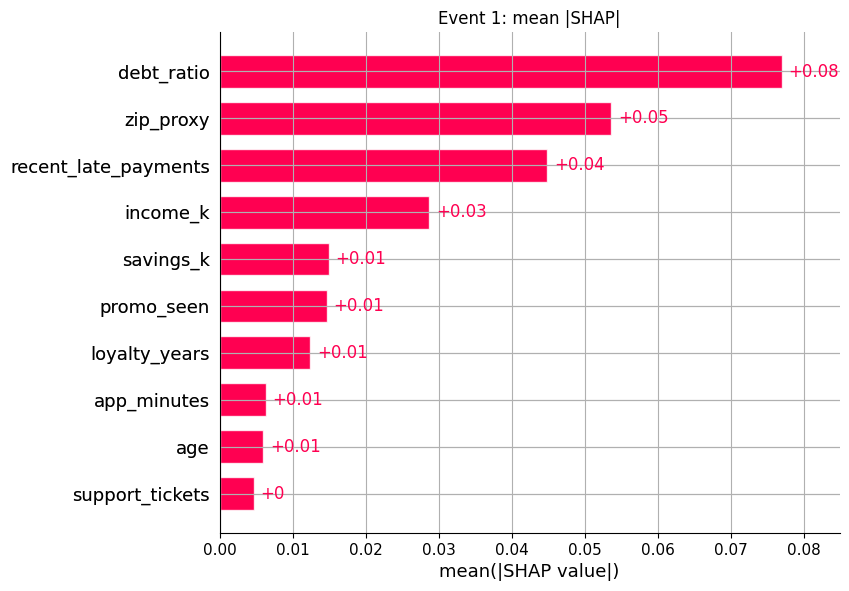

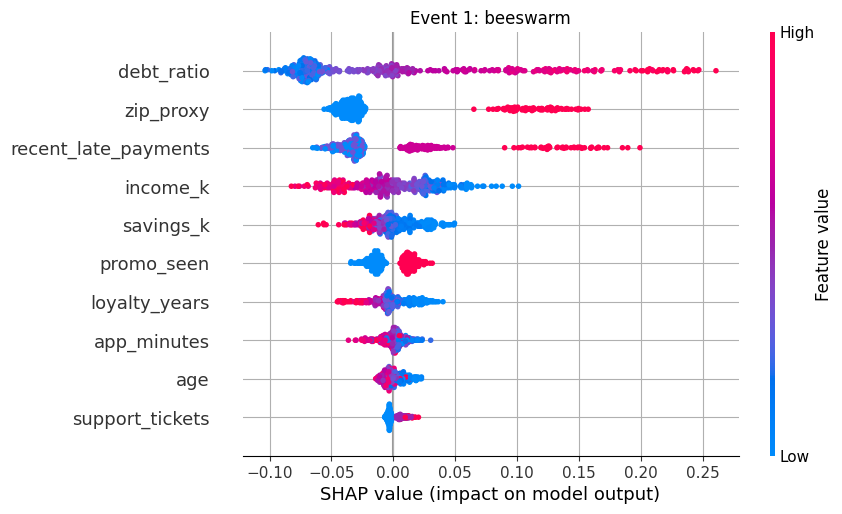

,debt_ratio,income_k,zip_proxy,promo_seen,recent_late_payments
debt_ratio,1.00,0.00,0.16,0.02,0.25
income_k,0.00,1.00,-0.16,-0.04,-0.02
zip_proxy,0.16,-0.16,1.00,0.25,0.08
promo_seen,0.02,-0.04,0.25,1.00,-0.01
recent_late_payments,0.25,-0.02,0.08,-0.01,1.00


In [10]:
# Event 1: mean |SHAP| over the 400 sampled test rows
importance = pd.Series(
    np.abs(tab_sv.values).mean(axis=0), index=feature_names
).sort_values(ascending=False)
print(importance.round(4))

shap.plots.bar(tab_sv, max_display=10, show=False)
plt.title("Event 1: mean |SHAP|")
plt.show()

shap.plots.beeswarm(tab_sv, max_display=10, show=False)
plt.title("Event 1: beeswarm")
plt.show()

# checking correlations because shap can split credit between correlated features
display(
    X_train[
        ["debt_ratio", "income_k", "zip_proxy", "promo_seen", "recent_late_payments"]
    ]
    .corr()
    .round(2)
)

### Event 1 result
**Output:** mean |SHAP| ranking, bar plot and beeswarm (400 test rows).

**Claim:** debt_ratio is the most important feature (0.077), then zip_proxy (0.054) and recent_late_payments (0.045).

**Evidence quality:** Pretty good. TreeSHAP is exact for random forests and the beeswarm also shows direction (high debt, more late payments, zip_proxy = 1 and lower income all increase risk). app_minutes is near the bottom which makes sense. I also checked the correlations because correlated features can split credit, but they're all pretty low (0.25 at most), so I don't think that's a big problem here. What surprised me is that zip_proxy is second, which seems like a problem if it's a location proxy.

**Medal:** Gold. It's still just what the model uses though, not what actually causes risk.

## Event 2: Explain One Specific Prediction

**Question:** Why did this individual tabular prediction occur?

**Target:** Tabular local case

**Your task:** Use `tabular_local_case` and explain the model's prediction for that row. Your answer should refer to row-specific evidence.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

row 718: true=0, P(high risk)=0.499
base 0.224 + sum of shap 0.275 = 0.499


,value,shap
zip_proxy,1.0000,0.1541
income_k,48.8969,0.0473
savings_k,1.1474,0.0449
recent_late_payments,2.0000,0.0411
debt_ratio,0.2812,-0.0251
app_minutes,13.1063,0.0181
loyalty_years,8.9812,-0.0139
promo_seen,1.0000,0.0139
age,38.0000,-0.0028
support_tickets,0.0000,-0.0027


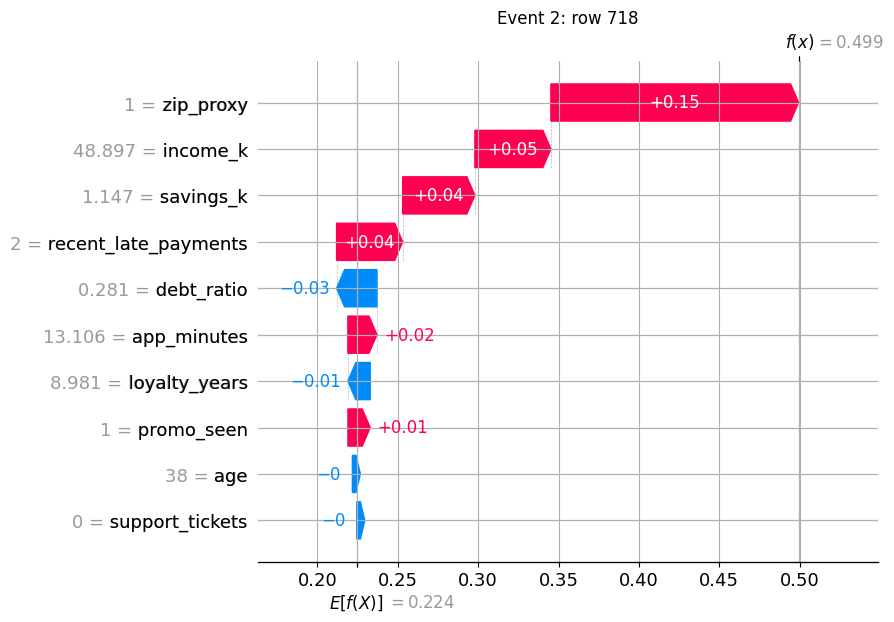

In [11]:
# Event 2: explain tabular_local_case
idx = tabular_local_case
e = tabular_shap_row(idx)
print(f"row {idx}: true={y_test.iloc[idx]}, P(high risk)={tabular_proba[idx]:.3f}")
print(
    f"base {e.base_values:.3f} + sum of shap {e.values.sum():.3f} = {e.base_values + e.values.sum():.3f}"
)
display(shap_table(idx))
shap.plots.waterfall(e, max_display=10, show=False)
plt.title(f"Event 2: row {idx}")
plt.show()

### Event 2 result
**Output:** waterfall plot and SHAP table for tabular_local_case (row 718).

**Claim:** This row is at 0.499 mostly because zip_proxy = 1 (+0.154). Low income, low savings and 2 late payments each add a bit more, and the low debt_ratio lowers it slightly.

**Evidence quality:** Good, it's specific to this row and the numbers add up exactly (0.224 + 0.275 = 0.499).

**Medal:** Gold

## Event 3: Detect Dataset Bias or a Shortcut

**Question:** Is the image model relying on a spurious shortcut?

**Target:** Image shortcut probe

**Your task:** Investigate whether the classifier uses the red corner marker, the shape, or both. Your method may need adaptation if it is not an image method.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

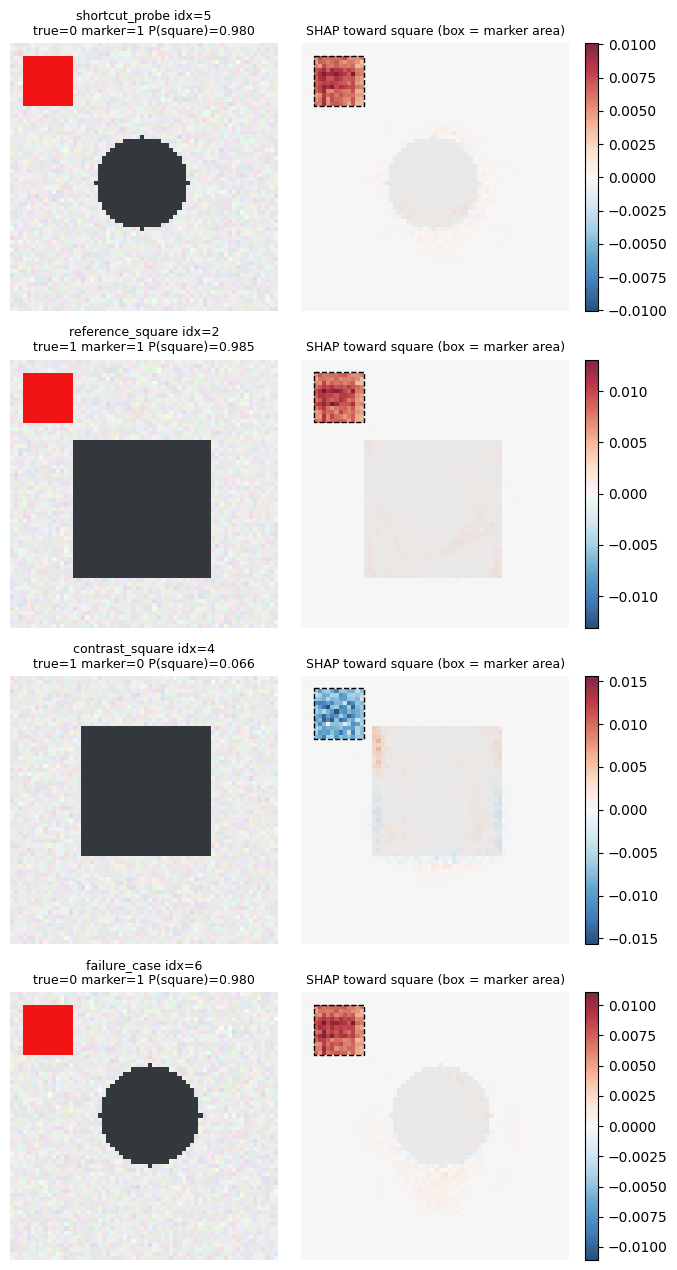

,marker_share,shape_share,marker_signed,shape_signed
shortcut_probe,0.816,0.042,0.893,0.038
reference_square,0.786,0.186,1.140,0.258
contrast_square,0.682,0.231,-1.193,0.220
failure_case,0.795,0.045,0.995,0.050


marker_share  shape_share
marker_present true_label                           
0              circle             0.656        0.155
               square             0.693        0.172
1              circle             0.812        0.077
               square             0.807        0.114

marker area as % of image: 3.5


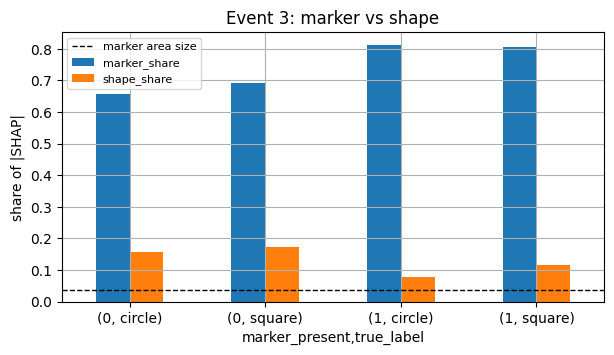

In [12]:
# Event 3: does the image model use the red marker?
case_idx = assigned_image_cases["image_index"].astype(int).tolist()
case_names = assigned_image_cases["case_name"].tolist()
case_maps = plot_image_shap(case_idx, case_names)
display(
    pd.DataFrame(
        [
            attribution_mass(case_maps[k, :, :, 1], test_imgs[i])
            for k, i in enumerate(case_idx)
        ],
        index=case_names,
    ).round(3)
)

# one heatmap isn't enough, so check the first 120 test images
probe_idx = np.arange(120)
probe_maps = image_shap(probe_idx, nsamples=100)
mass_df = pd.DataFrame(
    [
        attribution_mass(probe_maps[k, :, :, 1], test_imgs[i])
        for k, i in enumerate(probe_idx)
    ]
)
mass_df["marker_present"] = test_marker[probe_idx]
mass_df["true_label"] = np.where(test_y[probe_idx] == 1, "square", "circle")
summary3 = mass_df.groupby(["marker_present", "true_label"])[
    ["marker_share", "shape_share"]
].mean()
display(summary3.round(3))
print("marker area as % of image:", round(MARKER_MASK.mean() * 100, 1))

summary3.plot(kind="bar", figsize=(7, 3.5))
plt.axhline(MARKER_MASK.mean(), color="k", ls="--", lw=1, label="marker area size")
plt.ylabel("share of |SHAP|")
plt.title("Event 3: marker vs shape")
plt.legend(fontsize=8)
plt.xticks(rotation=0)
plt.show()

### Event 3 result
**Output:** SHAP heatmaps for the 4 image cases, and the share of SHAP in the marker area vs the shape for 120 test images.

**Claim:** Yes, the model uses the red marker. The marker area is only 3.5% of the pixels but gets about 80% of the SHAP when it's there. The shape gets around 8 to 17% on average. Even when there's no marker the corner still gets 66 to 69%, so the model is also using the fact that there's no red there.

**Evidence quality:** I think this is convincing because it holds across 120 images and not just one example. But it's still attribution, so to really prove it you would remove the marker and see if the prediction changes.

**Medal:** Gold

## Event 4: Understand a Feature's Global Effect

**Question:** As one tabular feature changes, what happens to predictions?

**Target:** Tabular risk model

**Your task:** Choose a feature such as `debt_ratio`, `income_k`, or `age`. Show how predictions change as that feature changes, or explain why your method cannot answer a global effect question.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

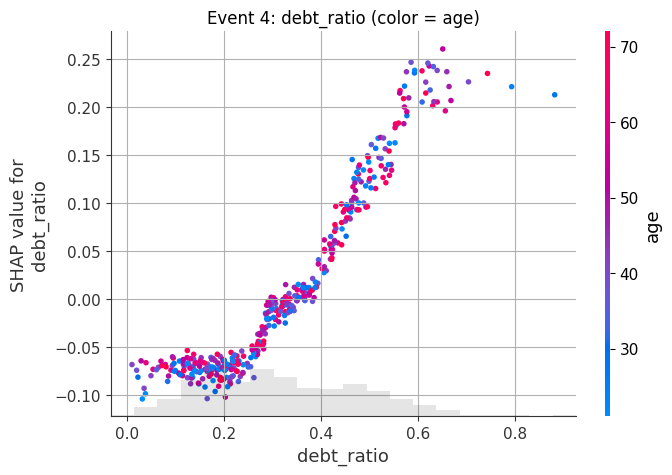

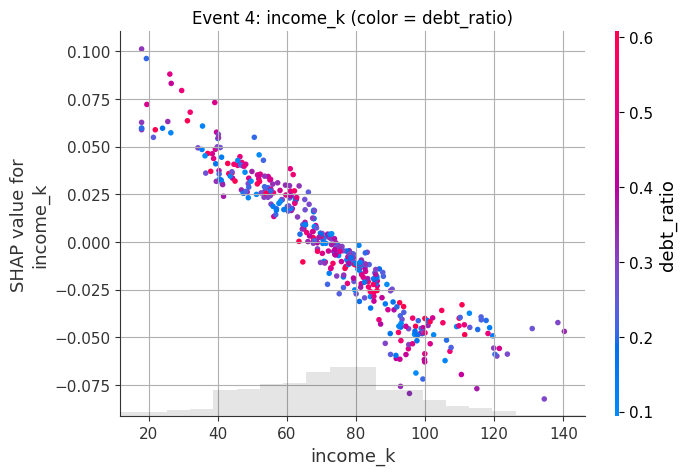

,mean,std,count
debt_ratio,,,
"(0.0, 0.15]",-0.073,0.010,61
"(0.15, 0.25]",-0.072,0.010,89
"(0.25, 0.35]",-0.021,0.021,90
"(0.35, 0.45]",0.036,0.030,61
"(0.45, 0.55]",0.123,0.025,60
"(0.55, 0.7]",0.214,0.024,35
"(0.7, 1.0]",0.224,0.009,4


In [13]:
# Event 4: dependence plots
for feat, color_by in [("debt_ratio", "age"), ("income_k", "debt_ratio")]:
    shap.plots.scatter(tab_sv[:, feat], color=tab_sv[:, color_by], show=False)
    plt.title(f"Event 4: {feat} (color = {color_by})")
    plt.show()

# average shap for debt_ratio in bins
bins = pd.cut(X_shap["debt_ratio"], [0, 0.15, 0.25, 0.35, 0.45, 0.55, 0.7, 1.0])
display(
    pd.Series(tab_sv[:, "debt_ratio"].values, index=X_shap.index)
    .groupby(bins, observed=True)
    .agg(["mean", "std", "count"])
    .round(3)
)

### Event 4 result
**Output:** SHAP dependence plots for debt_ratio and income_k, and average SHAP for debt_ratio in bins.

**Claim:** Below about 0.25 debt_ratio doesn't change much (around -0.07), between 0.25 and 0.6 the SHAP value goes up quickly, and above 0.6 it levels off (around +0.22). Higher income means lower risk.

**Evidence quality:** It's useful but not exactly what the question asks. The plot shows SHAP values for existing rows, not how the prediction changes if you only change debt_ratio. PDP or ALE would answer this more directly. Also there are only 4 rows above 0.7.

**Medal:** Silver

## Event 5: Compare Two Predictions

**Question:** Why were two cases classified differently?

**Target:** Tabular or image comparison cases

**Your task:** Compare `tabular_low_case` vs. `tabular_high_case`, or compare two assigned image cases. Explain the difference, not just each case separately.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

,low_value,high_value,shap_low,shap_high,diff
debt_ratio,0.044,0.536,-0.063,0.162,0.225
recent_late_payments,0.000,6.000,-0.025,0.186,0.211
zip_proxy,0.000,1.000,-0.024,0.105,0.129
income_k,102.549,38.814,-0.038,0.051,0.089
savings_k,18.423,3.738,-0.006,0.030,0.036
loyalty_years,21.356,1.485,-0.022,0.014,0.036
promo_seen,0.000,1.000,-0.010,0.015,0.025
age,54.000,28.000,-0.007,0.011,0.018
support_tickets,0.000,1.000,-0.003,0.005,0.008
app_minutes,23.506,23.557,-0.006,-0.016,-0.011


P(high risk): low 0.022, high 0.789, gap 0.766
sum of shap diffs: 0.766


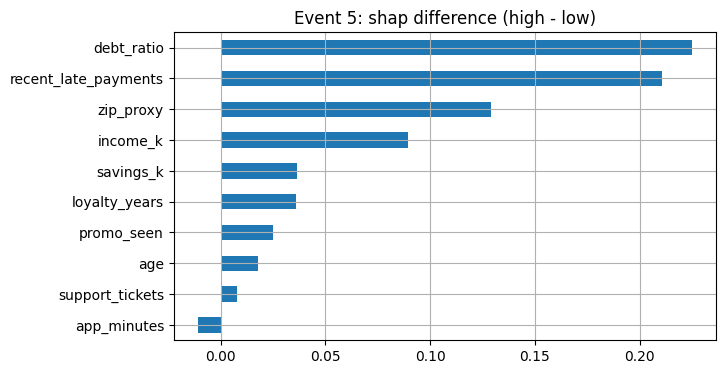

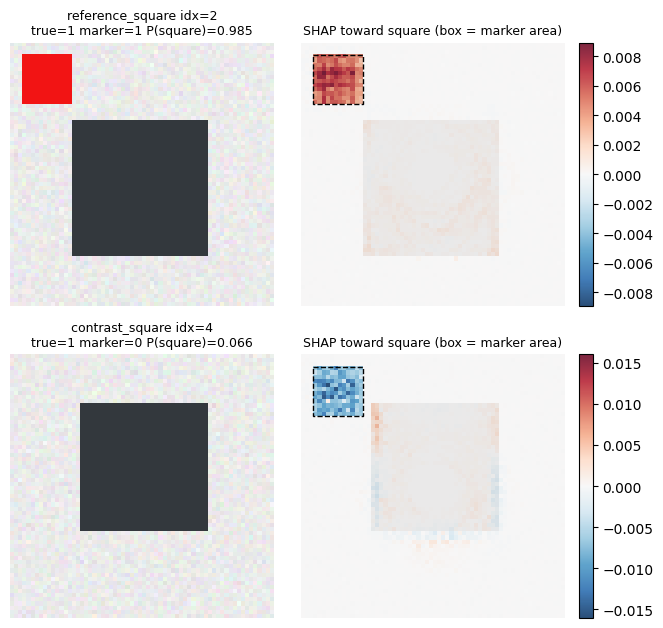

,marker_share,shape_share,marker_signed,shape_signed
reference_square,0.740,0.222,0.799,0.230
contrast_square,0.668,0.241,-1.200,0.215


In [14]:
# Event 5: low case vs high case
lo, hi = tabular_low_case, tabular_high_case
e_lo, e_hi = tabular_shap_row(lo), tabular_shap_row(hi)
comp = pd.DataFrame(
    {
        "low_value": X_test.iloc[lo].values,
        "high_value": X_test.iloc[hi].values,
        "shap_low": e_lo.values,
        "shap_high": e_hi.values,
    },
    index=feature_names,
)
comp["diff"] = comp["shap_high"] - comp["shap_low"]
comp = comp.sort_values("diff", ascending=False)
display(comp.round(3))
print(
    f"P(high risk): low {tabular_proba[lo]:.3f}, high {tabular_proba[hi]:.3f}, gap {tabular_proba[hi] - tabular_proba[lo]:.3f}"
)
print(f"sum of shap diffs: {comp['diff'].sum():.3f}")
comp["diff"].plot(kind="barh", figsize=(7, 4))
plt.gca().invert_yaxis()
plt.title("Event 5: shap difference (high - low)")
plt.show()

# also tried it on two squares, one with marker and one without
ref, con = image_reference_case, image_contrast_case
pair_maps = plot_image_shap([ref, con], ["reference_square", "contrast_square"])
display(
    pd.DataFrame(
        [
            attribution_mass(pair_maps[k, :, :, 1], test_imgs[i])
            for k, i in enumerate([ref, con])
        ],
        index=["reference_square", "contrast_square"],
    ).round(3)
)

### Event 5 result
**Output:** SHAP values for the low and high case side by side plus the difference. Also SHAP maps for reference_square vs contrast_square.

**Claim:** The gap of 0.766 is mostly from debt_ratio (0.225), late payments (0.211), zip_proxy (0.129) and income (0.089). For the images, both are real squares but one has the marker and one doesn't, and that's basically the whole difference. Their shape SHAP is almost the same.

**Evidence quality:** Good. Since both rows have the same base value, the SHAP differences add up exactly to the gap.

**Medal:** Gold

## Event 6: Detect Feature Interactions

**Question:** Which tabular variables work together?

**Target:** Tabular risk model

**Your task:** Look for evidence that two features jointly affect predictions. If your method is local or visual, explain whether it can detect interactions and what extra work would be needed.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

,feature_a,feature_b,interaction
0,debt_ratio,recent_late_payments,0.0113
1,income_k,zip_proxy,0.0096
2,debt_ratio,zip_proxy,0.0081
3,recent_late_payments,zip_proxy,0.0074
4,app_minutes,zip_proxy,0.0068
5,income_k,debt_ratio,0.0061
6,debt_ratio,savings_k,0.0055
7,income_k,recent_late_payments,0.0051


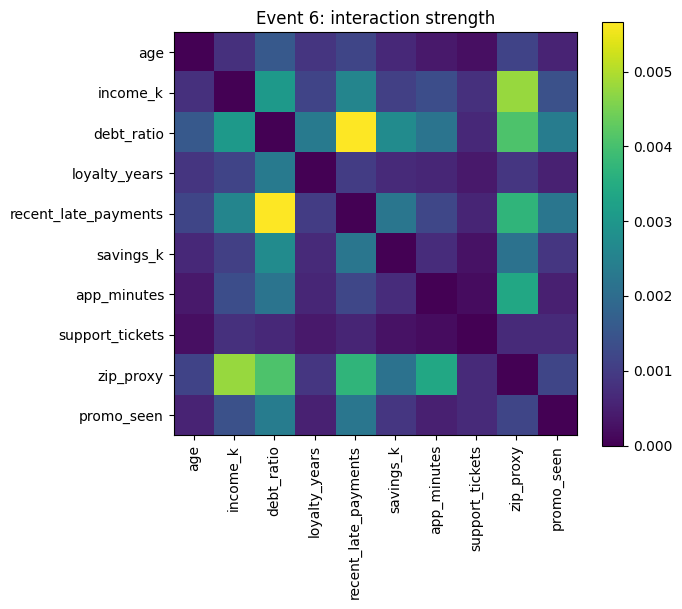

,n,mean age x debt interaction
"young, high debt",11.0,0.0092
"older, high debt",38.0,-0.0021
"young, low debt",51.0,-0.0017
"older, low debt",200.0,0.0004


In [15]:
# Event 6: shap interaction values (only works with TreeExplainer)
X_int = X_shap.iloc[:300]
inter = tree_explainer.shap_interaction_values(X_int)
inter = inter[..., 1]  # class 1
M = np.abs(inter).mean(axis=0)

pairs = [
    (feature_names[i], feature_names[j], 2 * M[i, j])
    for i in range(len(feature_names))
    for j in range(i + 1, len(feature_names))
]
pairs_df = (
    pd.DataFrame(pairs, columns=["feature_a", "feature_b", "interaction"])
    .sort_values("interaction", ascending=False)
    .reset_index(drop=True)
)
display(pairs_df.head(8).round(4))

off = M.copy()
np.fill_diagonal(off, 0)
plt.figure(figsize=(6.5, 5.5))
plt.imshow(off, cmap="viridis")
plt.xticks(range(10), feature_names, rotation=90)
plt.yticks(range(10), feature_names)
plt.colorbar()
plt.grid(False)
plt.title("Event 6: interaction strength")
plt.show()

# I wanted to check age x debt_ratio specifically (young people with high debt)
a, d = feature_names.index("age"), feature_names.index("debt_ratio")
age_debt = 2 * inter[:, a, d]
young, high_debt = (X_int["age"] < 30).values, (X_int["debt_ratio"] > 0.48).values
groups = {
    "young, high debt": young & high_debt,
    "older, high debt": ~young & high_debt,
    "young, low debt": young & ~high_debt,
    "older, low debt": ~young & ~high_debt,
}
display(
    pd.DataFrame(
        {
            g: {"n": m.sum(), "mean age x debt interaction": age_debt[m].mean()}
            for g, m in groups.items()
        }
    ).T.round(4)
)

### Event 6 result
**Output:** SHAP interaction values, top pairs, heatmap, and a check for age x debt_ratio.

**Claim:** The strongest interactions are between debt_ratio, recent_late_payments, zip_proxy and income_k. There is an age x debt_ratio interaction but only for young people with high debt.

**Evidence quality:** Partial. Some of these interactions might just come from the output being a probability (the curve flattens at the ends), so they aren't necessarily real interactions. The age x debt one only has 11 rows and I wouldn't have found it from the ranking alone. Also app_minutes x zip_proxy is 5th on the list even though app_minutes barely matters by itself, so I think some of these are just noise. And this only works with TreeExplainer.

**Medal:** Silver

## Event 7: Find Where the Model Is Looking

**Question:** What region of an image drives the prediction?

**Target:** Image model

**Your task:** Use one or more assigned image cases. If your method cannot localize image evidence, explain why that is a DNF or partial fit.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

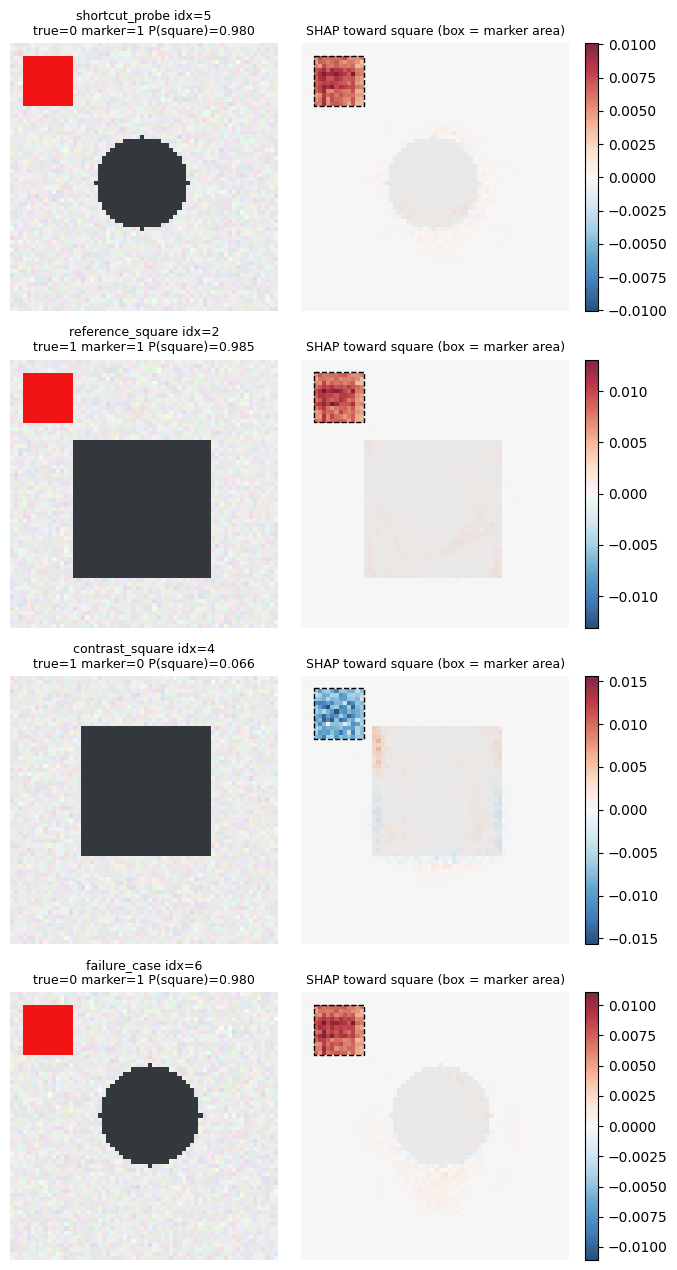

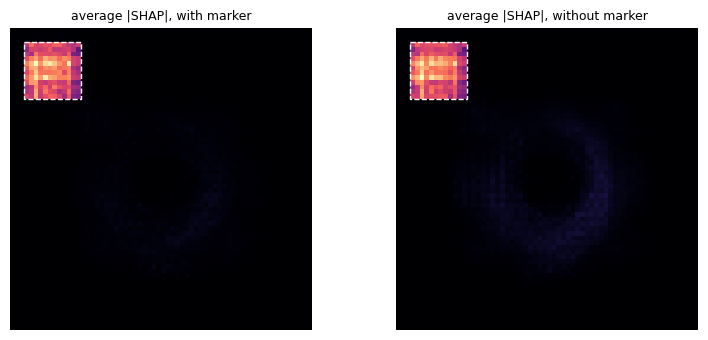

In [16]:
# Event 7: heatmaps again + average |shap| map
_ = plot_image_shap(case_idx, case_names, maps=case_maps)

avg_with = np.abs(probe_maps[test_marker[probe_idx] == 1, :, :, 1]).mean(axis=0)
avg_without = np.abs(probe_maps[test_marker[probe_idx] == 0, :, :, 1]).mean(axis=0)
fig, ax = plt.subplots(1, 2, figsize=(8, 3.5))
for a_, m_, t_ in [
    (ax[0], avg_with, "with marker"),
    (ax[1], avg_without, "without marker"),
]:
    a_.imshow(m_, cmap="magma")
    a_.add_patch(Rectangle((2.5, 2.5), 12, 12, fill=False, ec="w", ls="--"))
    a_.set_title(f"average |SHAP|, {t_}", fontsize=9)
    a_.axis("off")
plt.tight_layout()
plt.show()

### Event 7 result
**Output:** heatmaps for the 4 cases and average |SHAP| maps with and without the marker.

**Claim:** The model looks at the top left corner where the marker is, not the shape. Red there pushes toward square and no red pushes toward circle.

**Evidence quality:** Very clear in all cases and on average. The pixel maps are a bit noisy but the corner stands out a lot.

**Medal:** Gold

## Event 8: Explain a Failure

**Question:** Why did the model make this mistake?

**Target:** Tabular and/or image failure case

**Your task:** Use `tabular_failure_case` or `image_failure_case`. Explain the likely reason for the incorrect prediction using your method, or explain why it cannot diagnose a single failure.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

row 1: true=1, P(high risk)=0.400


,value,shap
debt_ratio,0.7236,0.2381
recent_late_payments,1.0000,-0.0544
zip_proxy,0.0000,-0.0343
promo_seen,1.0000,0.0220
savings_k,5.9755,0.0042
support_tickets,0.0000,-0.0024
age,31.0000,0.0013
income_k,66.0762,0.0011
app_minutes,16.1129,-0.0003
loyalty_years,2.7923,-0.0002


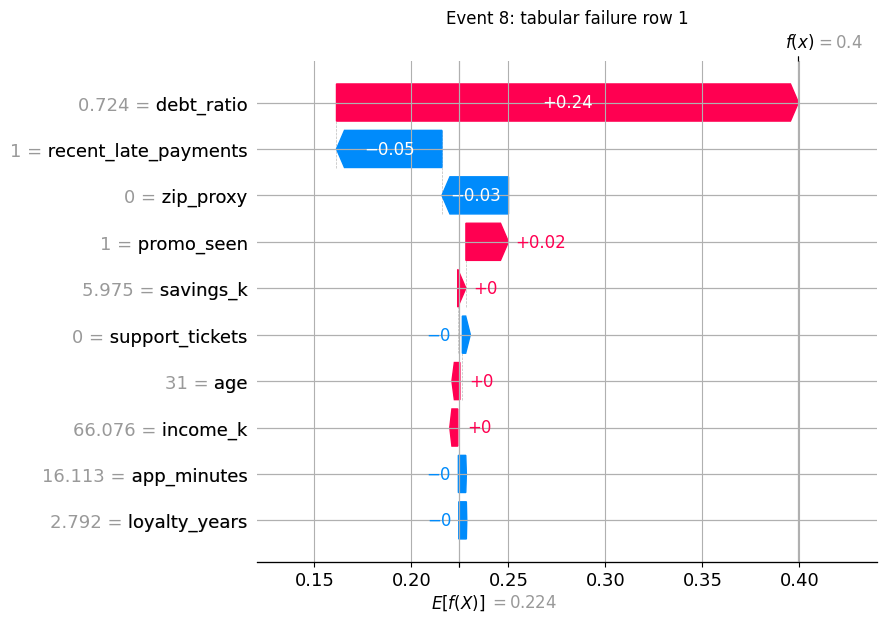

,age,debt_ratio,recent_late_payments,zip_proxy,income_k
mean,45.66,0.59,2.74,0.68,60.94
50%,46.50,0.59,3.00,1.00,55.85


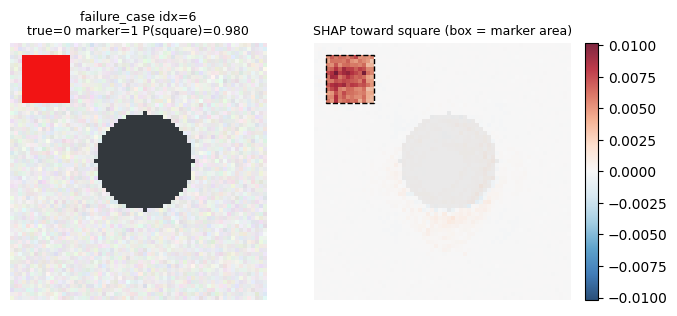

marker_share     0.812
shape_share      0.050
marker_signed    0.870
shape_signed     0.049
dtype: float64


In [17]:
# Event 8a: tabular failure case
idx = tabular_failure_case
print(f"row {idx}: true={y_test.iloc[idx]}, P(high risk)={tabular_proba[idx]:.3f}")
display(shap_table(idx))
shap.plots.waterfall(tabular_shap_row(idx), max_display=10, show=False)
plt.title(f"Event 8: tabular failure row {idx}")
plt.show()

# compare with high risk rows the model got right
tp_rows = np.where((tabular_pred == 1) & (y_test.to_numpy() == 1))[0]
display(
    X_test.iloc[tp_rows][
        ["age", "debt_ratio", "recent_late_payments", "zip_proxy", "income_k"]
    ]
    .describe()
    .loc[["mean", "50%"]]
    .round(2)
)

# Event 8b: image failure case
fail_maps = plot_image_shap([image_failure_case], ["failure_case"])
print(
    pd.Series(
        attribution_mass(fail_maps[0, :, :, 1], test_imgs[image_failure_case])
    ).round(3)
)

### Event 8 result
**Output:** waterfall for the tabular failure case, heatmap for the image failure case.

**Claim:** Image: it's a circle with a marker and the model says square because almost all the SHAP is on the marker, so it's the shortcut again. Tabular: row 1 is actually high risk but got 0.40. The debt_ratio is very high (0.72) and adds 0.24, but it only has 1 late payment and zip_proxy = 0, which pull it down. Most of the high risk rows the model got right have around 3 late payments and zip_proxy = 1, so this row doesn't look like them.

**Evidence quality:** Clear for the image, but it's basically the same situation as the shortcut probe in Event 3 (circle with marker, P = 0.98), so it doesn't add much new. For the tabular case it makes sense but I can't tell if the model is wrong or if the label is just noise (the labels are randomly sampled from a probability).

**Medal:** Silver

## Event 9: Estimate Trustworthiness

**Question:** Should a human trust this prediction?

**Target:** Either target model

**Your task:** Use your method to argue for or against trusting one prediction. Be specific about what your method can and cannot establish.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

In [18]:
# Event 9: trust
# how often is zip_proxy the biggest driver?
top_feature = pd.Series(
    np.array(feature_names)[np.abs(tab_sv.values).argmax(axis=1)], index=X_shap.index
)
print(top_feature.value_counts())
print(
    "zip_proxy is the top driver in",
    round((top_feature == "zip_proxy").mean() * 100, 1),
    "% of rows",
)

# stability check 1: path dependent vs interventional TreeSHAP for the local case
interv = shap.TreeExplainer(
    risk_model,
    data=X_train.sample(100, random_state=SEED),
    feature_perturbation="interventional",
)
e_int = interv(X_test.iloc[[tabular_local_case]])[:, :, 1][0]
stab = pd.DataFrame(
    {
        "path_dependent": tabular_shap_row(tabular_local_case).values,
        "interventional": e_int.values,
    },
    index=feature_names,
).round(4)
display(stab.sort_values("path_dependent", key=np.abs, ascending=False))

# stability check 2: image shap with a different background set
alt_bg = to_tensor_images(
    train_imgs[
        np.random.default_rng(SEED + 1).choice(len(train_imgs), 100, replace=False)
    ]
).to(DEVICE)
alt_explainer = shap.GradientExplainer(image_model, alt_bg)
m1 = image_shap([image_shortcut_case])[0, :, :, 1]
m2 = image_shap([image_shortcut_case], explainer=alt_explainer)[0, :, :, 1]
print(
    "marker share, background A vs B:",
    round(attribution_mass(m1, test_imgs[image_shortcut_case])["marker_share"], 3),
    round(attribution_mass(m2, test_imgs[image_shortcut_case])["marker_share"], 3),
)
print(
    "correlation between the two maps:",
    round(np.corrcoef(m1.ravel(), m2.ravel())[0, 1], 3),
)

debt_ratio              238
zip_proxy                96
recent_late_payments     44
income_k                 13
loyalty_years             6
savings_k                 3
Name: count, dtype: int64
zip_proxy is the top driver in 24.0 % of rows


,path_dependent,interventional
zip_proxy,0.1541,0.1476
income_k,0.0473,0.0505
savings_k,0.0449,0.0475
recent_late_payments,0.0411,0.0443
debt_ratio,-0.0251,-0.0279
app_minutes,0.0181,0.0242
loyalty_years,-0.0139,-0.0105
promo_seen,0.0139,0.0126
age,-0.0028,-0.0014
support_tickets,-0.0027,-0.0026


marker share, background A vs B: 0.816 0.837
correlation between the two maps: 0.995


### Event 9 result
**Output:** how often zip_proxy is the top feature, two stability checks.

**Claim:** I wouldn't trust row 718 without someone checking it, since it's basically 50/50 and mostly based on zip_proxy. zip_proxy is the top driver in 24% of rows. I wouldn't trust the image model at all. Both stability checks gave almost the same results, so this isn't just because of the SHAP settings.

**Evidence quality:** SHAP is good for finding reasons not to trust a prediction, but it can't tell you a prediction is right. It doesn't give uncertainty or calibration.

**Medal:** Silver

## Event 10: Reverse Engineer the Model

**Question:** What strategy has each model learned?

**Target:** Both target models

**Your task:** Synthesize evidence across events. A single output is usually not enough; explain what your method revealed and what remains unknown.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

In [19]:
# Event 10: putting the earlier results together
print("feature ranking (event 1):")
print(importance.round(4))
print("\ntop interactions (event 6):")
print(pairs_df.head(3).round(4))
print("\nmarker vs shape (event 3):")
print(summary3.round(3))

feature ranking (event 1):
debt_ratio              0.0770
zip_proxy               0.0536
recent_late_payments    0.0449
income_k                0.0287
savings_k               0.0149
promo_seen              0.0147
loyalty_years           0.0124
app_minutes             0.0063
age                     0.0060
support_tickets         0.0047
dtype: float64

top interactions (event 6):
    feature_a             feature_b  interaction
0  debt_ratio  recent_late_payments       0.0113
1    income_k             zip_proxy       0.0096
2  debt_ratio             zip_proxy       0.0081

marker vs shape (event 3):
                           marker_share  shape_share
marker_present true_label                           
0              circle             0.656        0.155
               square             0.693        0.172
1              circle             0.812        0.077
               square             0.807        0.114


### Event 10 result
**Tabular:** high debt_ratio, lots of late payments, zip_proxy = 1 and low income/savings lead to high risk. app_minutes, support_tickets and age don't matter much on their own. zip_proxy being this important seems like a fairness issue.

**Image:** red corner means square, no red corner means circle. The shape barely matters. This fits with the test accuracy being about 50%, since the test set has the marker on random images.

**Evidence quality:** Combining the earlier events gives a decent picture, but SHAP only describes what the model does. It didn't give exact rules and I didn't test anything causally.

**Medal:** Silver

# Final Model Profile

**Tabular model strategy:**  
The model mostly uses debt_ratio, recent_late_payments, zip_proxy and income_k. The debt_ratio effect is S-shaped (flat at first, then goes up fast between about 0.25 and 0.6). app_minutes and support_tickets barely matter. The part that worried me is zip_proxy: it's second overall and the main driver in about a quarter of the rows, including the borderline case in Event 2. I found some interactions and a small age x debt_ratio effect for young people with high debt, but SHAP didn't show that one clearly.

**Image model strategy:**  
It uses the red marker and not the shape. The marker area is 3.5% of the image but gets around 80% of the SHAP when the marker is there. A circle with a marker gets called a square (P = 0.98) and a square without one gets called a circle. That explains why the test accuracy is around 50%.

**Your method's decathlon profile:**  
SHAP did well on questions about which features pushed a prediction and by how much: global importance (1), single predictions (2), comparing two cases (5), and finding where the image model looks (3, 7). It was only partly useful for global effects (4) and interactions (6) because it shows attributions and not what happens when you change a feature, and interactions only really work for tree models. For failures, trust and overall strategy (8, 9, 10) it gave useful hints but can't prove anything causal or give uncertainty. I'd say it's best for "why did the model predict this".

**Open questions:**  
I'd like to see if someone using counterfactuals can confirm that removing the marker flips the prediction. I'm also curious if PDP or ALE for debt_ratio look the same as my dependence plot, and if a 2D ALE plot shows the age x debt_ratio interaction more clearly.

# Reflection Questions

**If you used 2 XAI approaches, how do you think your decathlon results improve?**

If I added counterfactuals to SHAP, I think the results would get a lot better because they answer different things. SHAP shows which features the model used and how much, and counterfactuals show what would need to change to flip the prediction.

For Event 3 and 8, SHAP shows the marker gets most of the attribution, but with counterfactuals I could actually remove the marker and see if the circle gets predicted as a circle. That would be real proof instead of just attribution. For Event 5, I could find the smallest change that turns the low risk case into high risk, which is closer to how people actually ask "why A and not B". For Event 9, if changing only zip_proxy flips someone's prediction, that's a pretty clear reason not to trust it and it would also help with checking fairness. For Event 4, changing debt_ratio while keeping everything else the same would show how the prediction actually changes, which the SHAP dependence plot doesn't really do (although this is closer to what PDP or ICE does).

So I think Events 4, 8, 9 and 10 could each go up one medal. I don't think Event 6 would change much, since a counterfactual is still about one case and doesn't really show which features work together.

**What would still be missing after implementing both approaches together?**

Both methods still only explain the model, not the real world. For example they can't tell us if the model should be using zip_proxy at all. It's the second most important feature and it drives the borderline case in Event 2, but whether that's okay is a fairness question, and that needs fairness metrics and people who know the domain, not more XAI. Neither method gives uncertainty either, which matters for a case like row 718 that's at 0.499. And for the tabular failure case in Event 8, neither one can tell if the model was actually wrong or if the label is just noise, since the labels were randomly sampled from a probability.
